## This notebook translates my AI-augmented EDA into executive recommendations.

Examples:

* Revenue drivers
* Customer segmentation
* Franchise comparison
* High-value customers
* Churn indicators
* KPI dashboard tables

End with:

Top 10 Strategic Recommendations

In [1]:
import pandas as pd
import requests

kpi_per_day = "https://raw.githubusercontent.com/alijrizvi/enterprise-ai-customer-churn-prediction-platform/main/data/kpi_per-day-shifts.csv"
data_by_customer = "https://raw.githubusercontent.com/alijrizvi/enterprise-ai-customer-churn-prediction-platform/main/data/data-by-customer.csv"
data_by_date = "https://raw.githubusercontent.com/alijrizvi/enterprise-ai-customer-churn-prediction-platform/main/data/data-by-date.csv"
data_by_product = "https://raw.githubusercontent.com/alijrizvi/enterprise-ai-customer-churn-prediction-platform/main/data/data-by-product.csv"

# gold_ml_features = "https://raw.githubusercontent.com/alijrizvi/enterprise-ai-customer-churn-prediction-platform/main/data/gold_ml-ready_customer-features.csv"

# 2. Read the CSV directly into a Pandas DataFrame
df1 = pd.read_csv(kpi_per_day)
df2 = pd.read_csv(data_by_customer)
df3 = pd.read_csv(data_by_date)
df4 = pd.read_csv(data_by_product)
# df5 = pd.read_csv(gold_ml_features)

In [2]:
# Let's Check each
# The Data Types had been Inspected already previously, so will focus on the work itself

print("df1 (kpi_per_day) head:")
display(df1.head())

print("\ndf2 (data_by_customer) head:")
display(df2.head())

print("\ndf3 (data_by_date) head:")
display(df3.head())

print("\ndf4 (data_by_product) head:")
display(df4.head())

df1 (kpi_per_day) head:


,franchiseID,date,total_earnings,pct_change_earnings_per_day,total_earnings_per_unit,pct_change_total_earnings_per_unit_per_day,avg_quantity_bought,pct_change_avg_quantity_bought_per_day
0,3000000,2024-05-01,24,NaN,6,NaN,4.000000,NaN
1,3000000,2024-05-02,204,750.00,18,200.00,11.333333,183.33
2,3000000,2024-05-03,282,38.24,21,16.67,13.428571,18.49
3,3000000,2024-05-04,96,-65.96,9,-57.14,10.666667,-20.57
4,3000000,2024-05-05,252,162.50,21,133.33,12.000000,12.50



df2 (data_by_customer) head:


,customerID,total_purchases,unique_products_bought,total_products_bought,total_spent
0,2000000,9,4,67,201
1,2000001,8,4,51,153
2,2000002,17,5,109,327
3,2000003,13,5,72,216
4,2000004,17,6,121,363



df3 (data_by_date) head:


,Date,total_customers,unique_transactions,unique_products_bought,total_products_bought,total_spent
0,2024-05-01,149,207,6,1376,4128
1,2024-05-02,138,190,6,1358,4074
2,2024-05-03,149,204,6,1426,4278
3,2024-05-04,138,190,6,1274,3822
4,2024-05-05,136,181,6,1315,3945



df4 (data_by_product) head:


,product,total_times_bought,total_payment_methods,total_quantity_bought,avg_spent_per_unit,total_spent
0,Golden Gate Ginger,586,3,3865,3,11595
1,Austin Almond Biscotti,530,3,3716,3,11148
2,Pearly Pies,550,3,3595,3,10785
3,Tokyo Tidbits,583,3,3662,3,10986
4,Outback Oatmeal,561,3,3733,3,11199


In [3]:
# Data Cleaning & Standardization

# Convert 'date' column to datetime in df1
df1['date'] = pd.to_datetime(df1['date'])

# Convert 'Date' column to datetime in df3
df3['Date'] = pd.to_datetime(df3['Date'])

# Fill missing values in percentage change columns of df1 with 0
# These NaNs typically occur on the first day where a percentage change from a prior day cannot be calculated.
df1['pct_change_earnings_per_day'] = df1['pct_change_earnings_per_day'].fillna(0)
df1['pct_change_total_earnings_per_unit_per_day'] = df1['pct_change_total_earnings_per_unit_per_day'].fillna(0)
df1['pct_change_avg_quantity_bought_per_day'] = df1['pct_change_avg_quantity_bought_per_day'].fillna(0)

print("Data types after conversion and missing values after imputation:")
print("\ndf1 info:")
df1.info()
print("\ndf3 info:")
df3.info()

Data types after conversion and missing values after imputation:

df1 info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 8 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   franchiseID                                 806 non-null    int64         
 1   date                                        806 non-null    datetime64[ns]
 2   total_earnings                              806 non-null    int64         
 3   pct_change_earnings_per_day                 806 non-null    float64       
 4   total_earnings_per_unit                     806 non-null    int64         
 5   pct_change_total_earnings_per_unit_per_day  806 non-null    float64       
 6   avg_quantity_bought                         806 non-null    float64       
 7   pct_change_avg_quantity_bought_per_day      806 non-null    float64       
dtypes: datetime64[n

### 1. Revenue Drivers and KPI Dashboard Tables

* Daily Earnings, and at the Unit level (Granularity), by Franchise and across Time
* Customer Spending Patterns
* Etc.

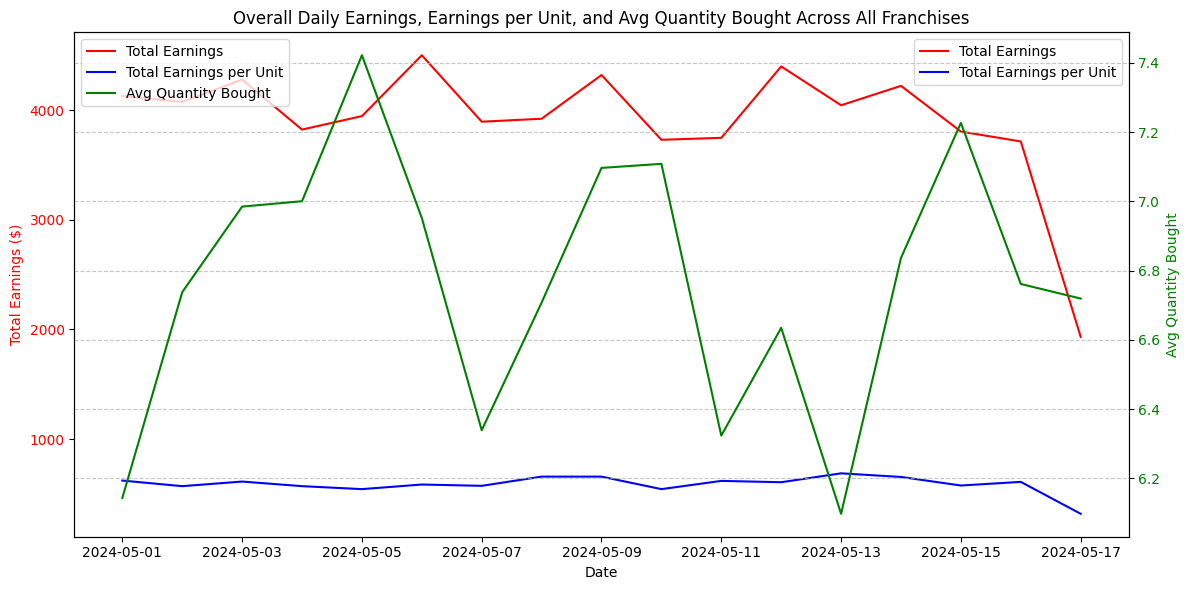

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Daily Earnings across Time
overall_daily_earnings = df1.groupby('date')[['total_earnings',
                                              'total_earnings_per_unit']].sum().reset_index()

# Daily Avg Product Quantity Sold
overall_daily_avg_quantity_sold = df1.groupby('date')['avg_quantity_bought'].mean().reset_index()


# Plotting Overall Daily Earnings
fig, ax1 = plt.subplots(figsize = (12, 6))

sns.lineplot(x = 'date', y = 'total_earnings', data = overall_daily_earnings,
             color = 'red', ax = ax1, label = 'Total Earnings')
sns.lineplot(x = 'date', y = 'total_earnings_per_unit', data = overall_daily_earnings,
             color = 'blue', ax = ax1, label = 'Total Earnings per Unit')

ax1.set_xlabel('Date')
ax1.set_ylabel('Total Earnings ($)', color = 'red')
ax1.tick_params(axis = 'y', labelcolor = 'red')

# Create a second y-axis for avg_quantity_bought
ax2 = ax1.twinx()
sns.lineplot(x = 'date', y = 'avg_quantity_bought', data = overall_daily_avg_quantity_sold,
             color = 'green', ax = ax2, label = 'Avg Quantity Bought')
ax2.set_ylabel('Avg Quantity Bought', color = 'green')
ax2.tick_params(axis = 'y', labelcolor = 'green')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc = 'upper left')

plt.title('Overall Daily Earnings, Earnings per Unit, and Avg Quantity Bought Across All Franchises')
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

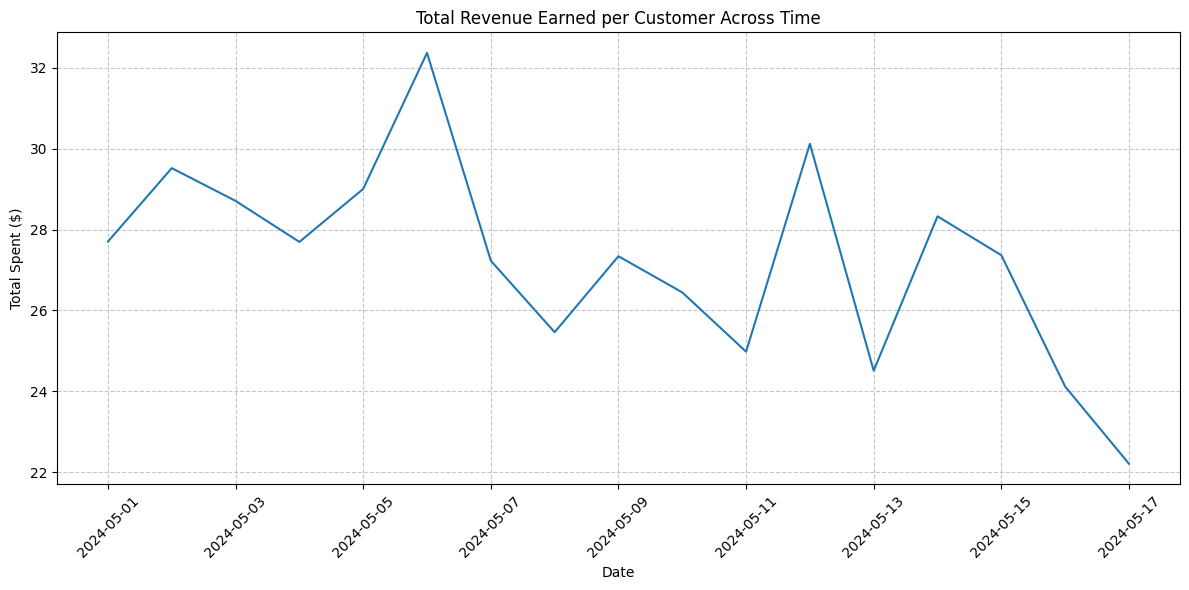

In [12]:
# Plotting total spent from df3
plt.figure(figsize = (12, 6))
sns.lineplot(x = df3['Date'], y = (df3['total_spent']/df3['total_customers']))
plt.title('Total Revenue Earned per Customer Across Time')
plt.xlabel('Date')
plt.ylabel('Total Spent ($)')
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### Franchise Comparison: Daily Earnings per Franchise

To understand revenue drivers further and enable franchise comparison, let's visualize the daily earnings for each franchise. This will highlight individual franchise performance and trends.

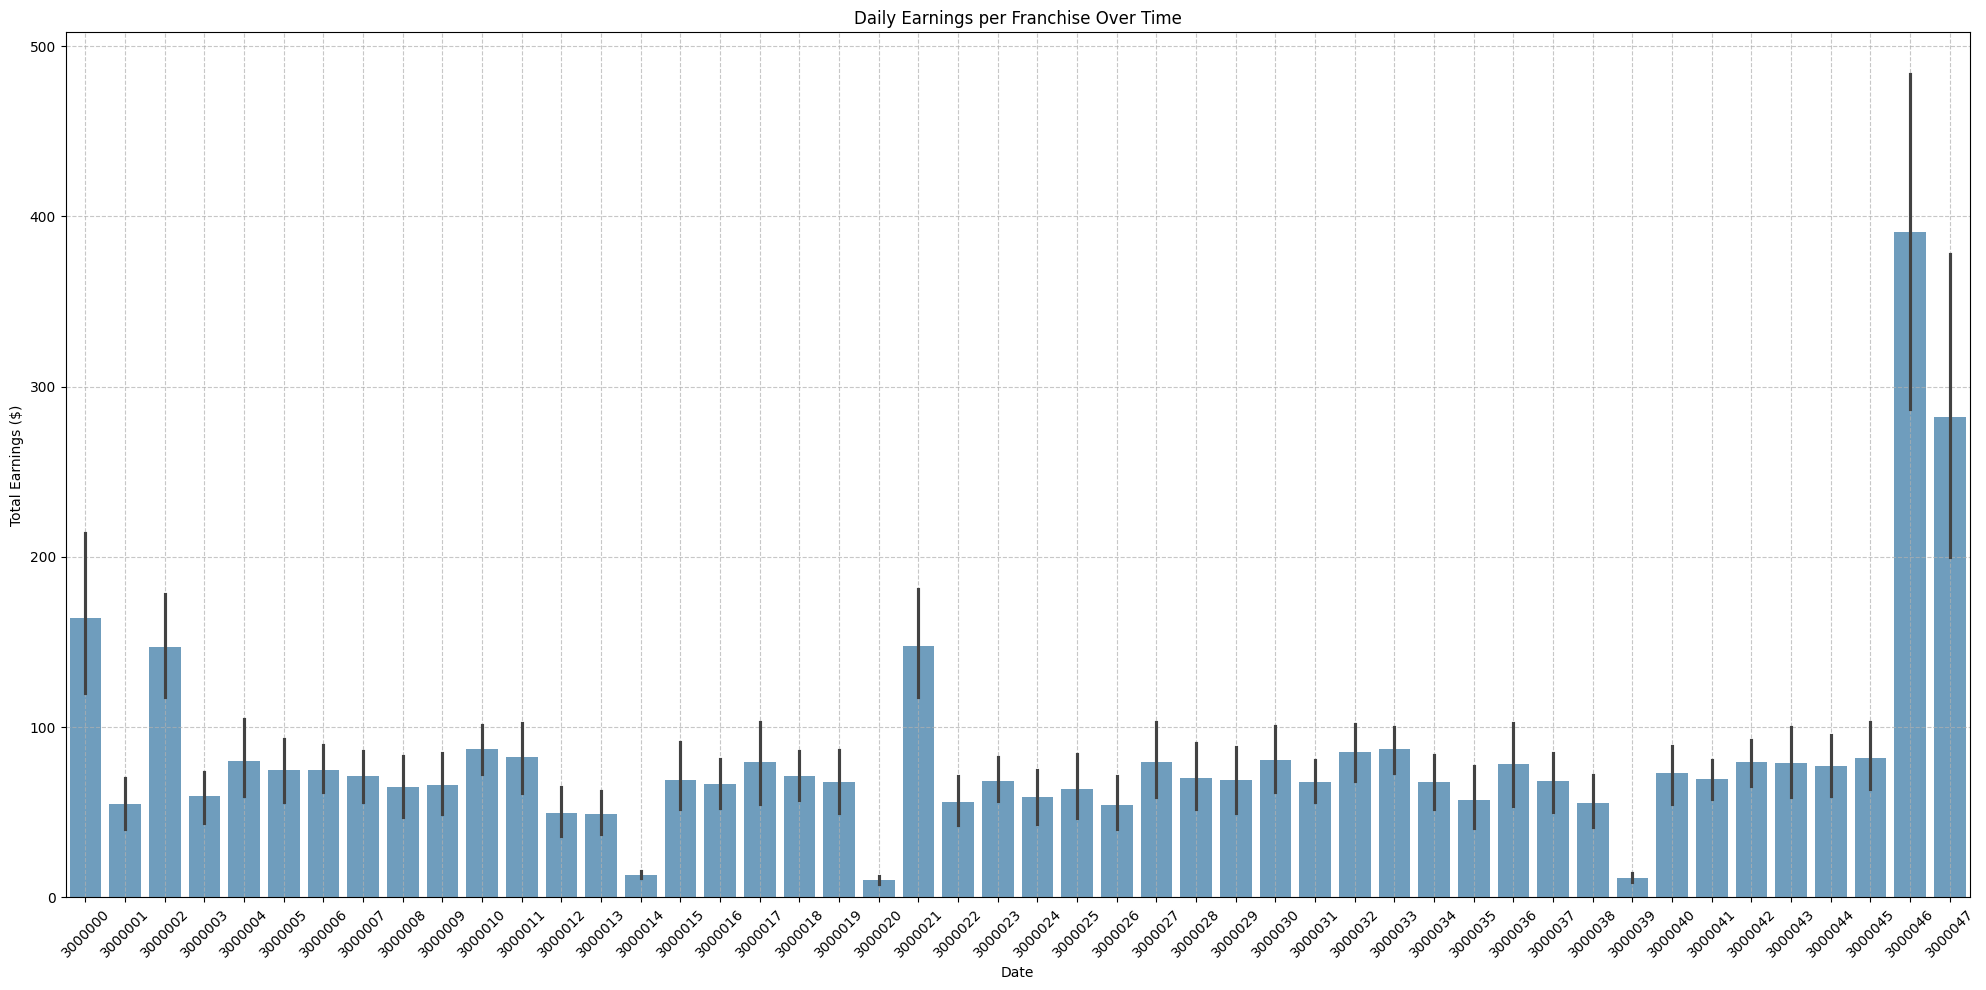

In [6]:
# Plotting Daily Earnings for each Franchise
plt.figure(figsize = (20, 10))
sns.barplot(x = 'franchiseID', y = 'total_earnings', data = df1, alpha = 0.7)
plt.title('Daily Earnings per Franchise Over Time')
plt.xlabel('Date')
plt.ylabel('Total Earnings ($)')
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### 2. Customer Segmentation and High-Value Customers

To identify high-value customers and understand customer segmentation, we will analyze the distribution of `total_spent` for each customer.


Summary statistics for Total Spent per Customer:
count    300.000000
mean     221.570000
std       92.822439
min       42.000000
25%      156.000000
50%      204.000000
75%      279.000000
max      672.000000
Name: total_spent, dtype: float64


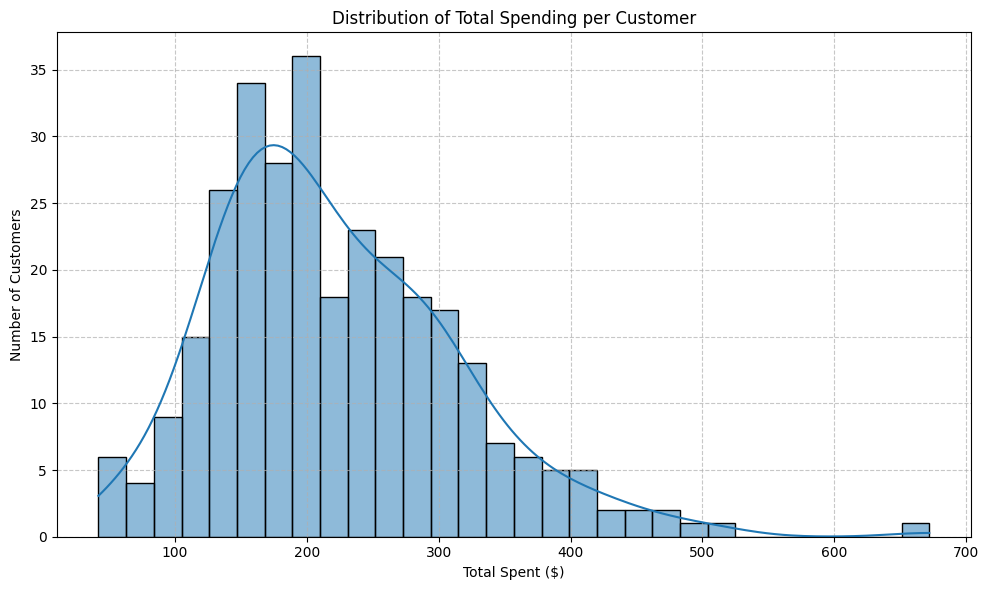

In [13]:
# Display Summary Statistics for total_spent
print("\nSummary Statistics for Total Spent per Customer:")
print(df2['total_spent'].describe())

# Plotting the Distribution of total_spent per Customer
plt.figure(figsize = (10, 6))
sns.histplot(df2['total_spent'], bins = 30, kde = True)
plt.title('Distribution of Total Spending per Customer')
plt.xlabel('Total Spent ($)')
plt.ylabel('Number of Customers')
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()



---

## Franchise Segmentation?

The latter franchises (3000046 and 3000047) recorded the highest Revenues.

Perhaps they also had more Items sold?

* Yes, that was it exactly! The 2nd graph shows that these highest-earners actually had the lowest Revenue-per-Item. Just the sheer count of Products they sold earned them so much Revenue.
* Actually, in terms of efficiency, the initial and two of the mid-end ones (3000032 and 3000034) were the most profitable Franchises per Unit of Item sold.

---

### Will get more into this form of Analysis in the ML phase of the project

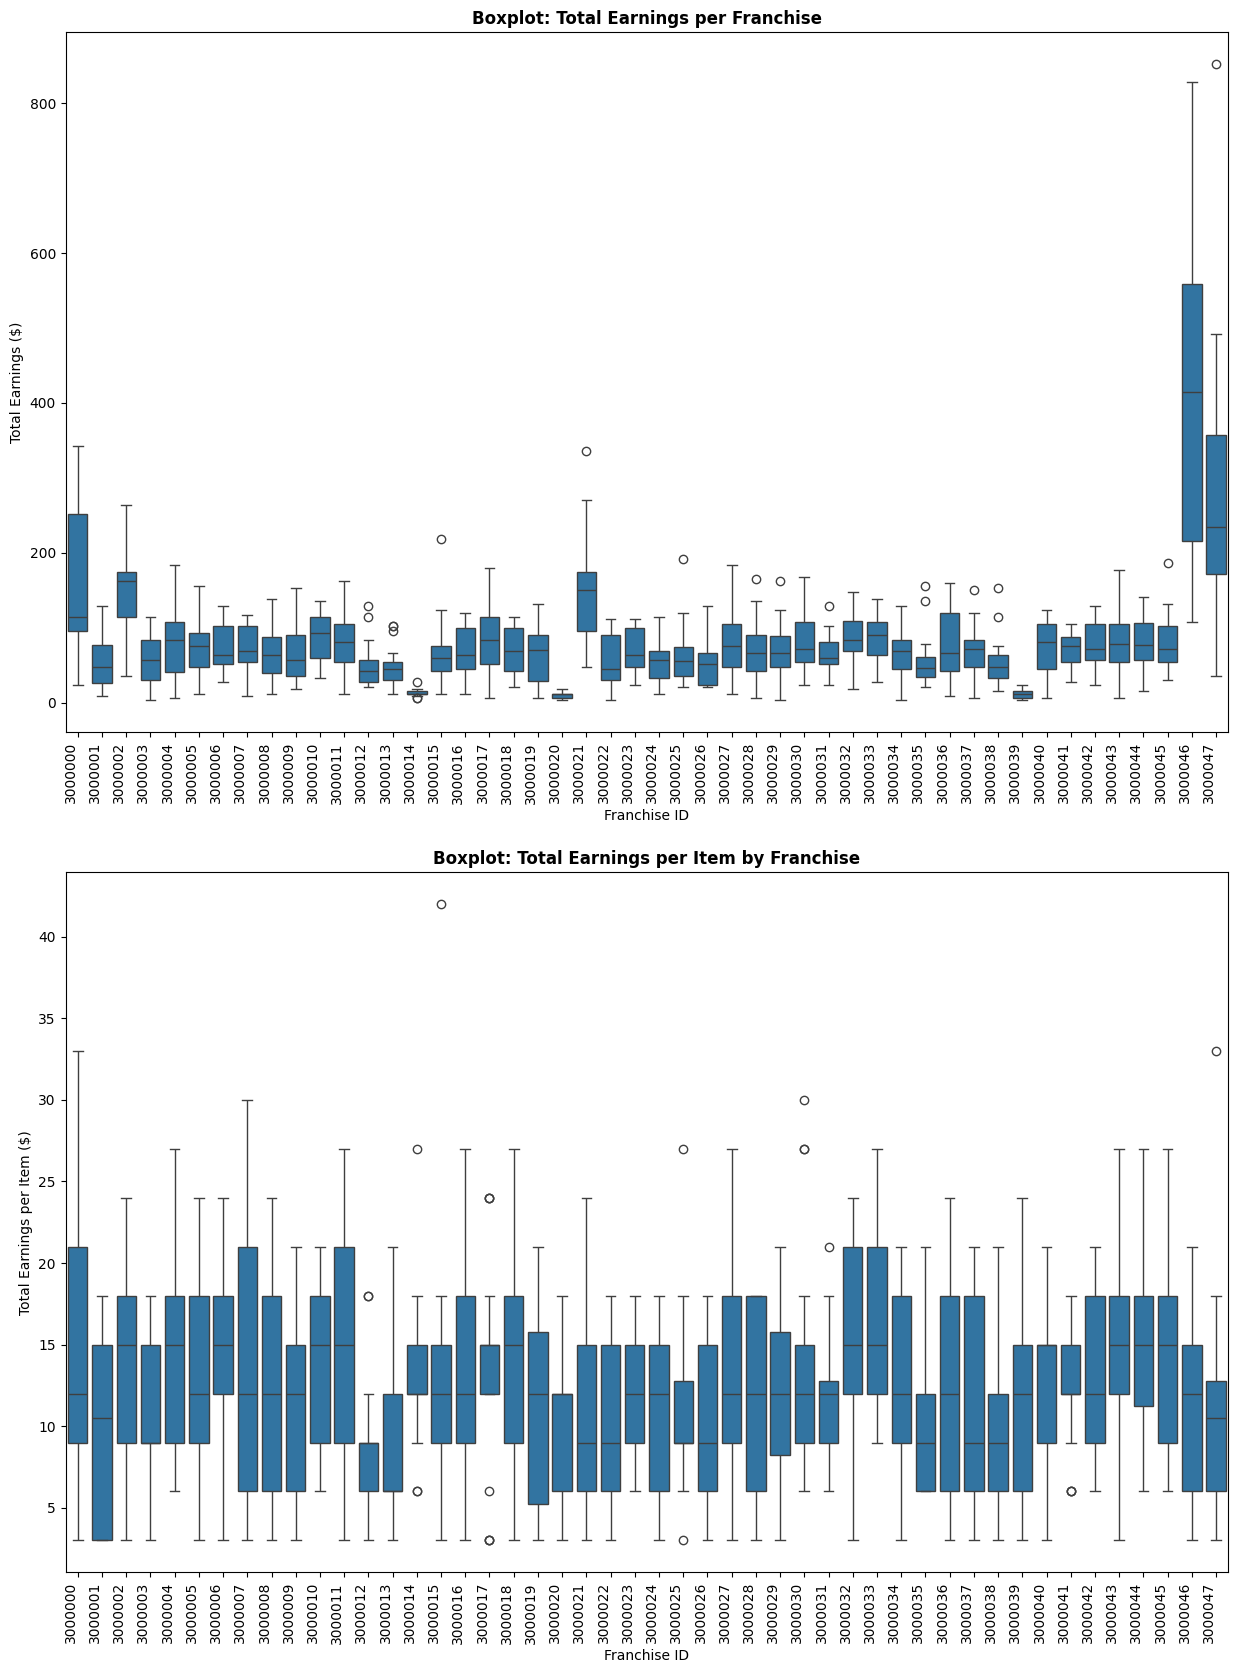

In [41]:
plt.figure(figsize = (15, 20))

plt.subplot(2, 1, 1)
sns.boxplot(x = df1['franchiseID'], y = df1['total_earnings'])
plt.xlabel('Franchise ID')
plt.ylabel('Total Earnings ($)')
plt.title('Boxplot: Total Earnings per Franchise', fontweight = 'bold')
plt.xticks(rotation = 90, ha = 'right')

plt.subplot(2, 1, 2)
sns.boxplot(x = df1['franchiseID'], y = df1['total_earnings_per_unit'])
plt.xlabel('Franchise ID')
plt.ylabel('Total Earnings per Item ($)')
plt.title('Boxplot: Total Earnings per Item by Franchise', fontweight = 'bold')
plt.xticks(rotation = 90, ha = 'right')

plt.show()